STARR FROM THE BEGINING...I DONT KNOW WHAT WILL HAPPEN 

objective---

1-Complete structure, ready to be directly copied and run in a Jupyter Notebook

2-Includes both ViT and ResNet（One Notebook；Two Models；The Same Dataset；The Same Training Loop--Control variables:
Same Dataset
Same Split 
Same Loss 
Same Optimizer 
Same Epoch ）

3-Fully aligned with the regression objective outlined in your PDF

4-Freezes the backbone, training only the regression head

In [102]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter

In [103]:
data_dir = "dataset"

image_paths = []
labels = []

level_mapping = {
    "LEV1-Conservative_change": 0.0,
    "LEV2-Partially_change": 0.25,
    "LEV3-Completely_change_into_specific_items": 0.5,
    "LEV4-Almost_abstract_shape_with_a_bit_inherent_feature": 0.75,
    "LEV5-Completely_abstract": 1.0
}

for folder_name in level_mapping:
    folder_path = os.path.join(data_dir, folder_name)

    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(folder_path, file_name))
            labels.append(level_mapping[folder_name])  # 反转

print("Distribution:", Counter(labels))

Distribution: Counter({0.25: 124, 0.75: 104, 0.5: 47, 0.0: 24, 1.0: 15})


In [104]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=42
)

In [105]:
class CatDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

In [106]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = CatDataset(train_paths, train_labels, transform)
val_dataset = CatDataset(val_paths, val_labels, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

In [107]:
class ResNetRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            "resnet50",
            pretrained=True,
            num_classes=0
        )

        # ✅ FREEZE ALL
        for param in self.backbone.parameters():
            param.requires_grad = False

        # ✅ UNFREEZE ALL
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        self.regressor = nn.Linear(self.backbone.num_features, 1)

    def forward(self, x):
        features = self.backbone(x)
        output = self.regressor(features)
        return torch.sigmoid(output)

In [108]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("Trainable params:", trainable)
print("Total params:", total)

Trainable params: 14966785
Total params: 23510081


In [109]:
def train_model(model, train_loader, val_loader, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {train_loss/len(train_loader):.4f}")

    return model

In [110]:
model = ResNetRegression()
model = train_model(model, train_loader, val_loader, epochs=7)

Epoch 1, Loss: 0.0668
Epoch 2, Loss: 0.0363
Epoch 3, Loss: 0.0151
Epoch 4, Loss: 0.0090
Epoch 5, Loss: 0.0078
Epoch 6, Loss: 0.0059
Epoch 7, Loss: 0.0043


In [111]:
def collect_predictions(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    preds = []
    labels = []

    with torch.no_grad():
        for images, target in loader:
            images = images.to(device)
            outputs = model(images)
            preds.extend(outputs.cpu().numpy().flatten())
            labels.extend(target.numpy())

    return np.array(preds), np.array(labels)

In [112]:
np.corrcoef(levels, means)[0,1]

0.8578107793552537

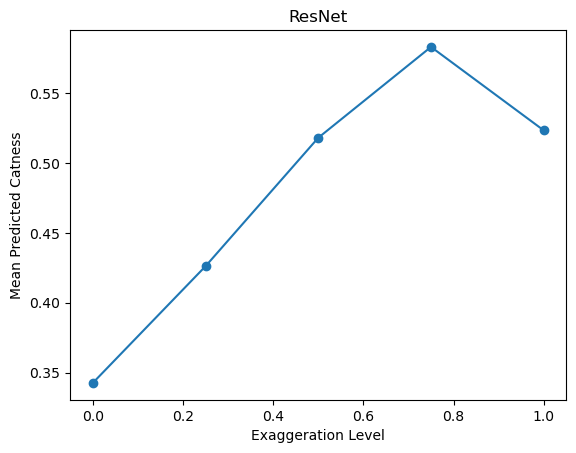

In [113]:
preds, labels = collect_predictions(model, val_loader)

levels = sorted(set(labels))
means = []

for l in levels:
    means.append(preds[labels == l].mean())

plt.plot(levels, means, marker='o')
plt.xlabel("Exaggeration Level")
plt.ylabel("Mean Predicted Catness")
plt.title("ResNet")
plt.show()